In [41]:
!pip install wrds

In [1]:
import wrds
db = wrds.Connection()

WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [2]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from typing import List, Dict, Optional




In [ ]:
def get_crsp_monthly_panel(db: wrds.Connection, start: str, end: str) -> pd.DataFrame:
    """Pull the CRSP monthly panel *with* security descriptors via a time-bounded
    join to msenames. This is necessary because shrcd/exchcd are not columns in
    MSF; they live in the name history tables.

    Filtering choices (my defaults for class):
    - U.S. common stocks only: shrcd in (10, 11)
    - Major exchanges only: exchcd in (1, 2, 3) # NYSE, AMEX, NASDAQ

    Returns
    -------
    DataFrame with: date, permno, prc, shrout, ret, and any columns needed for
    market cap construction and return math.
    """
    START_TS = pd.to_datetime(start)
    END_TS = pd.to_datetime(end)
    years = range(START_TS.year, END_TS.year + 1)

    frames: List[pd.DataFrame] = []
    for y in tqdm(years, desc="CRSP Query Progress"):
        chunk_start = f"{y}-01-01" if y > START_TS.year else start
        chunk_end = f"{y}-12-31" if y < END_TS.year else end

        # Time-bounded join ensures we take the *correct* security descriptor
        # (shrcd/exchcd) that was in force on each MSF observation date.
        q = f"""
            SELECT
                m.date,
                m.permno,
                m.prc,
                m.shrout,
                m.ret,
                n.shrcd,
                n.exchcd
            FROM crsp.msf AS m
            JOIN crsp.msenames AS n
                ON m.permno = n.permno
              AND m.date BETWEEN n.namedt
                              AND COALESCE(n.nameendt, DATE '9999-12-31')
            WHERE m.date BETWEEN '{chunk_start}' AND '{chunk_end}'
              AND n.shrcd IN (10, 11)  -- U.S. common shares
              AND n.exchcd IN (1, 2, 3) -- NYSE, AMEX, NASDAQ
              AND m.prc IS NOT NULL
              AND m.shrout IS NOT NULL
            ORDER BY m.date, m.permno;
        """
        frames.append(db.raw_sql(q))

    df = pd.concat(frames, ignore_index=True)

    # Standardize dtypes and construct market cap (for value-weighting and Top-N)
    df['date'] = pd.to_datetime(df['date'])
    df['prc'] = pd.to_numeric(df['prc'], errors='coerce').abs()  # CRSP may store signed prices
    df['shrout'] = pd.to_numeric(df['shrout'], errors='coerce') * 1000.0  # in thousands of shares
    df['ret'] = pd.to_numeric(df['ret'], errors='coerce')
    df['mktcap'] = df['prc'] * df['shrout']

    return df


In [6]:
def get_delistings(db: wrds.Connection, start: str, end: str) -> pd.DataFrame:
    """
    [Source: Logic from Workshop Notebook, Cell 3; required by Guide, Section 2.3]
    Pulls delisting returns from CRSP's msedelist table to address survivorship bias,
    as specified in Assign1.pdf, Part I, Task 4.
    """
    q = f"""
        SELECT permno, dlret, dlstdt AS date
        FROM crsp.msedelist
        WHERE dlstdt BETWEEN '{start}' AND '{end}'
    """
    delist_df = db.raw_sql(q, date_cols=['date'])
    delist_df['dlret'] = pd.to_numeric(delist_df['dlret'], errors='coerce')
    return delist_df

In [7]:
def add_effective_returns(panel: pd.DataFrame, delist: pd.DataFrame) -> pd.DataFrame:

  out = panel.merge(delist, on=['permno', 'date'], how='left')
  out['ret_eff'] = (1.0 + out['ret'].fillna(0.0)) * (1.0 + out['dlret'].fillna(0.0)) - 1.0
  return out

In [8]:
def get_etf_index(
    db: wrds.Connection, permno: int, start: str, end: str, label: str
) -> pd.Series:
    """
    Build a 100-based index level for an ETF by compounding monthly returns.
    Useful for quick benchmark overlays.

    Parameters
    ----------
    db : wrds.Connection
        Active WRDS database connection.
    permno : int
        CRSP PERMNO identifier of the ETF.
    start : str
        Start date (YYYY-MM-DD).
    end : str
        End date (YYYY-MM-DD).
    label : str
        Name to assign to the index series.

    Returns
    -------
    pd.Series
        A time series (indexed by date) of ETF index levels (base=100).
    """
    q = f"""
        SELECT date, ret
        FROM crsp.msf
        WHERE permno = {permno}
          AND date BETWEEN '{start}' AND '{end}'
        ORDER BY date;
    """

    d = db.raw_sql(q)
    d["date"] = pd.to_datetime(d["date"])
    d = d.sort_values("date")

    # Replace missing returns with 0 (no price change)
    d["ret"] = pd.to_numeric(d["ret"], errors="coerce").fillna(0.0)

    # Compound returns into an index (base = 100)
    idx = (1.0 + d["ret"]).cumprod() * 100.0
    idx.index = d["date"]
    idx.name = label

    return idx


In [9]:
def pick_permno_for_ticker(db: wrds.Connection, tkr: str, ref_date: pd.Timestamp) -> Optional[int]:
    """
    Finds the PERMNO for a ticker that was active on a specific reference date.
    This is a helper function to ensure the correct ETF is retrieved.
    """
    q = f"""
        SELECT permno FROM crsp.msenames
        WHERE ticker = '{tkr}'
        AND '{ref_date.strftime('%Y-%m-%d')}' BETWEEN namedt AND nameendt
        LIMIT 1
    """
    res = db.raw_sql(q)
    return res['permno'][0] if not res.empty else None


In [10]:
def build_topn_indexes(panel: pd.DataFrame, top_n: int) -> pd.DataFrame:
    """
    Construct Equal-, Value-, and Price-Weighted index levels (base=100).

    Methodology reminder:
    - At month t, choose constituents and weights from t-1 information.
    - Grow index from t-1 to t using ret_eff (includes delistings).

    Returns
    -------
    DataFrame with three columns (EW, VW, PW) indexed by month t.
    """
    # Organize by month for quick lookup
    panel = panel.sort_values(["date", "permno"])
    months = sorted(panel["date"].unique())
    by_month = {d: g for d, g in panel.groupby("date")}

    ew_level = [100.0]
    vw_level = [100.0]
    pw_level = [100.0]

    # Loop from the 2nd available month; need t-1 and t
    for i in tqdm(range(1, len(months)), desc="Index Calculation Progress"):
        t_1, t = months[i - 1], months[i]
        g_t1 = by_month[t_1].dropna(subset=["mktcap", "prc"])
        g_t = by_month[t]

        if g_t1.empty or g_t.empty:
            # If either month lacks data, carry forward
            ew_level.append(ew_level[-1])
            vw_level.append(vw_level[-1])
            pw_level.append(pw_level[-1])
            continue

        # Top-N by market cap at t-1 (investable, no look-ahead bias)
        chosen = (
            g_t1.sort_values("mktcap", ascending=False)
                .head(top_n)
                .set_index("permno")
        )

        # Ensure we have returns at t for the chosen PERMNOs
        g_t = g_t.set_index("permno")
        common = chosen.index.intersection(g_t.index)

        if len(common) == 0:
            ew_level.append(ew_level[-1])
            vw_level.append(vw_level[-1])
            pw_level.append(pw_level[-1])
            continue

        r_t = g_t.loc[common, "ret_eff"].astype(float)

        # Equal-Weighted: average of gross returns
        r_t_ew = r_t.dropna()
        ew_gross = (1.0 + r_t_ew).mean() if not r_t_ew.empty else 1.0

        # Value-Weighted: weights from t-1 market cap
        w_vw = chosen.loc[common, "mktcap"].astype(float)
        mask_vw = r_t.notna()
        w_vw = w_vw.loc[mask_vw]
        r_vw = r_t.loc[mask_vw]
        if w_vw.empty or w_vw.sum() <= 0:
            vw_gross = 1.0
        else:
            w_vw = w_vw / w_vw.sum()
            vw_gross = ((1.0 + r_vw) * w_vw).sum()

        # Price-Weighted: weights from t-1 price (Dow-style)
        w_pw = chosen.loc[common, "prc"].astype(float)
        mask_pw = r_t.notna()
        w_pw = w_pw.loc[mask_pw]
        r_pw = r_t.loc[mask_pw]
        if w_pw.empty or w_pw.sum() <= 0:
            pw_gross = 1.0
        else:
            w_pw = w_pw / w_pw.sum()
            pw_gross = ((1.0 + r_pw) * w_pw).sum()

        # Compound index levels
        ew_level.append(ew_level[-1] * float(ew_gross))
        vw_level.append(vw_level[-1] * float(vw_gross))
        pw_level.append(pw_level[-1] * float(pw_gross))

    # Convert results to a tidy DataFrame
    idx_months = pd.to_datetime(months[1:])
    ew = pd.Series(ew_level[1:], index=idx_months, name='Equal-Weighted')
    vw = pd.Series(vw_level[1:], index=idx_months, name='Value-Weighted')
    pw = pd.Series(pw_level[1:], index=idx_months, name='Price-Weighted')
    return pd.concat([ew, vw, pw], axis=1)


In [11]:
from typing import List
import pandas as pd
import numpy as np

def align_and_corr(levels: List[pd.Series]) -> pd.DataFrame:
    """
    Align multiple index level series to their common dates and compute
    the correlation matrix of log returns.

    Parameters
    ----------
    levels : List[pd.Series]
        A list of index level time series (e.g., ETF or portfolio indexes).

    Returns
    -------
    pd.DataFrame
        Correlation matrix of log returns across the input series.
    """
    # Find common dates across all series
    common = set(levels[0].index)
    for s in levels[1:]:
        common &= set(s.index)
    common = sorted(common)

    # Align each series to the common date index
    aligned = [s.loc[common] for s in levels]
    panel = pd.concat(aligned, axis=1)

    # Compute log returns and drop rows with missing values
    log_ret = np.log(panel / panel.shift(1)).dropna(how="any")

    return log_ret.corr()


In [19]:
def plot_indexes(custom_df: pd.DataFrame, etf_map: Dict[str, pd.Series], top_n: int):
    # --- Rebase custom indices to 100 ---
  df_rebased = custom_df / custom_df.iloc[0] * 100

  # --- Convert benchmarks dict to DataFrame and rebase to 100 ---
  benchmarks_df = pd.concat(etf_map, axis=1)  # keys become column names
  benchmarks_rebased = benchmarks_df / benchmarks_df.iloc[0] * 100

  # --- Plot ---
  fig, ax = plt.subplots(figsize=(12, 6))

  # Plot custom indices (solid lines by default)
  df_rebased.plot(ax=ax, logy=True, linewidth=1)

  # Plot benchmarks with dashed lines
  benchmarks_rebased.plot(ax=ax, logy=True, linestyle="--", linewidth=1)

  # Labels & Title
  ax.set_ylabel("Index Level (log scale, base=100)")
  ax.set_xlabel("Date")
  ax.set_title("Top 500 Custom Indexes vs Benchmarks")

  plt.legend(title="Indices")
  plt.show()


In [13]:
def show_corr_table(corr_mat: pd.DataFrame):

  plt.figure(figsize=(10, 8))
  sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=.5)

  plt.title("Correlation Matrix of Monthly Log Returns", fontsize=14, pad=15)
  plt.tight_layout()
  plt.show()


In [ ]:
START_DATE = '2000-07-01'
END_DATE = '2020-12-31'
TOP_N = 500  # Number of stocks to include in the index

print("\n[Step 1/5] Pulling CRSP MSF panel with universe filters")
panel = get_crsp_monthly_panel(db, START_DATE, END_DATE)
print(f"Rows pulled: {len(panel):,}")


[Step 1/5] Pulling CRSP MSF panel with universe filters


CRSP Query Progress: 100%|██████████| 21/21 [00:38<00:00,  1.81s/it]


Rows pulled: 1,056,430


In [21]:
panel.head()

,date,permno,prc,shrout,ret,shrcd,exchcd,mktcap,dlret,ret_eff
0,2000-07-31,10001,7.875,2475000.0,-0.015625,11,3,19490625.0,<NA>,-0.015625
1,2000-07-31,10002,10.1875,8587000.0,-0.012121,11,3,87480062.5,<NA>,-0.012121
2,2000-07-31,10009,32.875,2307000.0,0.005736,11,3,75842625.0,<NA>,0.005736
3,2000-07-31,10012,10.8125,19718000.0,-0.005747,11,3,213200875.0,<NA>,-0.005747
4,2000-07-31,10016,19.25,16947000.0,0.12,11,3,326229750.0,<NA>,0.12


In [15]:
print("[Step 2/5] Merging delisting returns and computing ret_eff")
delist = get_delistings(db, START_DATE, END_DATE)
panel = add_effective_returns(panel, delist)

[Step 2/5] Merging delisting returns and computing ret_eff


In [16]:
# Step 3: Build the custom Top-N indexes
print("[Step 3/5] Building Equal-, Value-, and Price-Weighted Top-N indexes")
custom_levels = build_topn_indexes(panel, TOP_N)

[Step 3/5] Building Equal-, Value-, and Price-Weighted Top-N indexes


Index Calculation Progress: 100%|██████████| 245/245 [00:01<00:00, 165.77it/s]


In [17]:
# Step 4: ETF benchmarks (SPY, IWM, QQQ)
print("[Step 4/5] Getting ETF benchmarks")
etf_tickers = ["SPY", "IWM", "QQQ"]
etf_series: Dict[str, pd.Series] = {}
START_TS = pd.to_datetime(START_DATE)

for tkr in etf_tickers:
    pno = pick_permno_for_ticker(db, tkr, START_TS)
    if pno is None:
        print(f"Warning: no PERMNO found for {tkr} near {START_DATE}. Skipping.")
        continue
    etf_series[tkr] = get_etf_index(db, pno, START_DATE, END_DATE, f"{tkr} (ETF)")

[Step 4/5] Getting ETF benchmarks


[Step 5/5] Plotting and computing correlations 



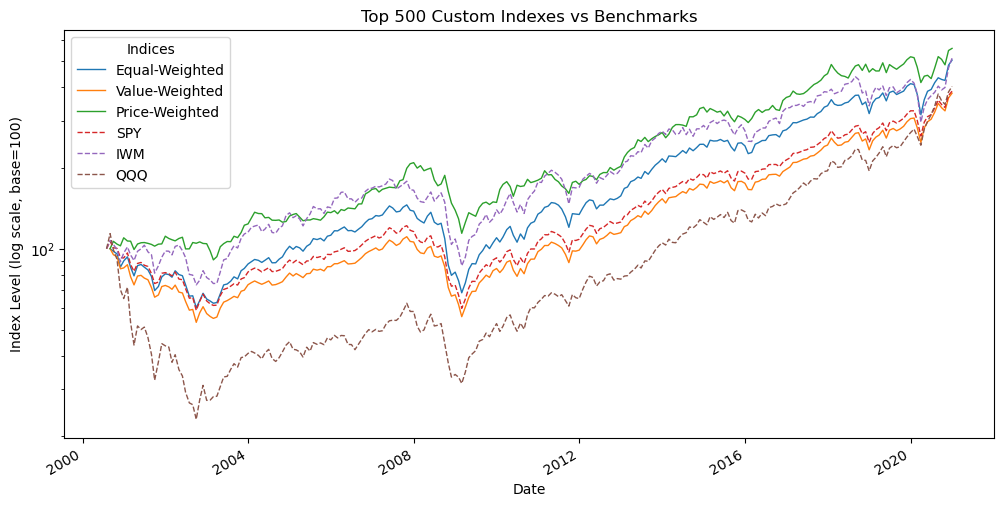

Correlation Matrix (monthly log returns):
                 Equal-Weighted  Value-Weighted  Price-Weighted  SPY (ETF)  \
Equal-Weighted        1.000000        0.974974        0.630756   0.973055   
Value-Weighted        0.974974        1.000000        0.643050   0.996326   
Price-Weighted        0.630756        0.643050        1.000000   0.632989   
SPY (ETF)             0.973055        0.996326        0.632989   1.000000   
IWM (ETF)             0.941506        0.891991        0.594161   0.893495   
QQQ (ETF)             0.842092        0.872609        0.420733   0.859673   

                IWM (ETF)  QQQ (ETF)  
Equal-Weighted   0.941506   0.842092  
Value-Weighted   0.891991   0.872609  
Price-Weighted   0.594161   0.420733  
SPY (ETF)        0.893495   0.859673  
IWM (ETF)        1.000000   0.759999  
QQQ (ETF)        0.759999   1.000000  


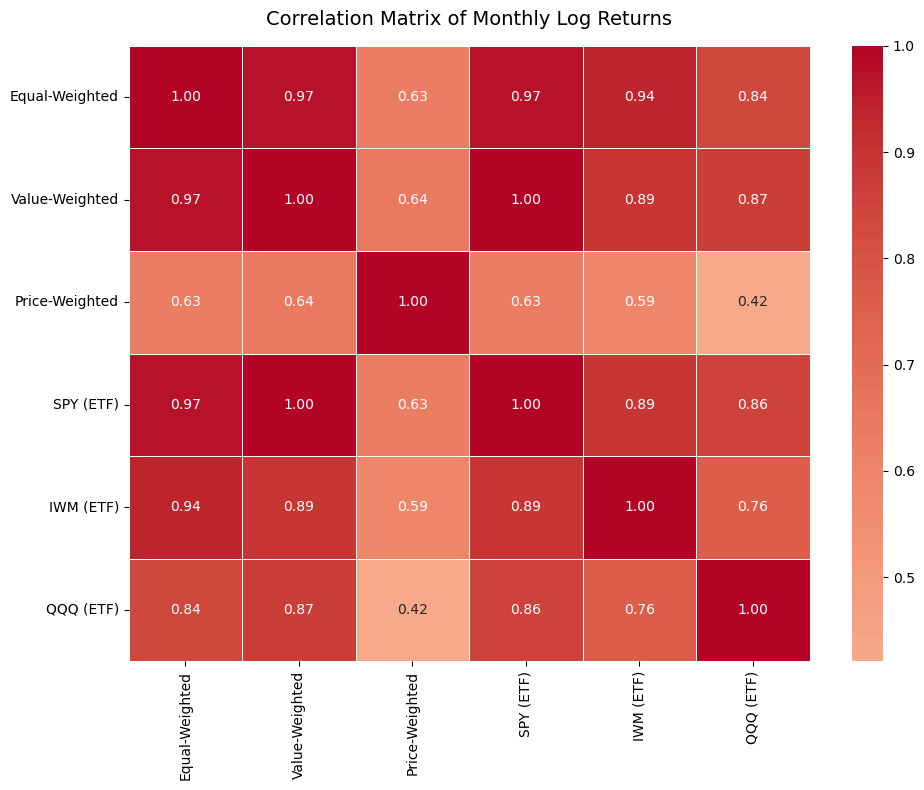

In [20]:
# Step 5: Plot the results
print("[Step 5/5] Plotting and computing correlations \n")
plot_indexes(custom_df=custom_levels, etf_map=etf_series, top_n=TOP_N)

# Align and compute correlation (monthly log returns) across all available series
all_series = [custom_levels[c] for c in custom_levels.columns] + list(etf_series.values())
corr_mat = align_and_corr(all_series)

print("Correlation Matrix (monthly log returns):\n", corr_mat)
show_corr_table(corr_mat)